In [43]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt 
from collections import defaultdict

import sys 



In [37]:
df2 = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\training_data\entire_odds_stats_2026-03-04.csv')
df1 = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\training_data\entire_odds_stats_2026-03-01.csv')
print(df1.shape, df2.shape)

(8137, 293) (8112, 293)


In [39]:
df1.tail()[['date', 'fighter_red', 'fighter_blue', 'elo_red']]

,date,fighter_red,fighter_blue,elo_red
8132,2026-02-21,nora cornolle,joselyne edwards,1522.560905
8133,2026-02-21,zach reese,michel pereira,1525.725516
8134,2026-02-21,serghei spivac,ante delija,1562.277172
8135,2026-02-21,chidi njokuani,carlos leal,1528.652077
8136,2026-02-21,ode osbourne,alibi idiris,1454.532654


In [40]:
df2.tail()[['date', 'fighter_red', 'fighter_blue', 'elo_red']]

,date,fighter_red,fighter_blue,elo_red
8107,2026-02-21,nora cornolle,joselyne edwards,1522.565036
8108,2026-02-21,zach reese,michel pereira,1525.725516
8109,2026-02-21,serghei spivac,ante delija,1562.276883
8110,2026-02-21,chidi njokuani,carlos leal,1528.651932
8111,2026-02-21,ode osbourne,alibi idiris,1454.532654


In [ ]:
fp = r'C:\Users\jcmar\my_files\SportsBetting\data\training_data\entire_odds_stats_2026-03-04.csv'
df_model = pd.read_csv(fp)

print("Before fill:", df_model[['reach_red', 'reach_blue']].isna().sum())

weight_classes = np.unique(df_model['weight_class'])

for c in weight_classes: 
    # Select all rows for this class (including NaNs)
    df_class = df_model[df_model['weight_class']==c].copy()
    
    # Compute class mean ignoring NaNs
    reach = (df_class['reach_red'].mean(skipna=True) + df_class['reach_blue'].mean(skipna=True)) / 2
    
    # Fill NaNs
    df_class[['reach_red','reach_blue']] = df_class[['reach_red','reach_blue']].fillna(reach)
    
    # Assign back to df_model
    df_model.loc[df_model['weight_class']==c, ['reach_red','reach_blue']] = df_class[['reach_red','reach_blue']]

print("After fill:", df_model[['reach_red', 'reach_blue']].isna().sum())

In [2]:
pd.set_option('display.max_rows', None)

In [36]:
df_rolling = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\features_test_files\ufc_new_rolling.csv')
# reminder that upcoming event features have to be in this dataframe 
df_rolling.isna().sum()

C:\Users\jcmar\AppData\Local\Temp\ipykernel_42852\1716389708.py:1: DtypeWarning: Columns (86,88) have mixed types. Specify dtype option on import or set low_memory=False.
  df_rolling = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\features_test_files\ufc_new_rolling.csv')


td_defense_pct_red                       796
td_total_attempted_against_red           791
td_total_landed_against_red              791
td_defense_pct_blue                     1637
td_total_attempted_against_blue         1633
td_total_landed_against_blue            1633
sig_str_defense_pct_red                  796
sig_str_total_attempted_against_red      791
sig_str_total_landed_against_red         791
sig_str_defense_pct_blue                1637
sig_str_total_attempted_against_blue    1633
sig_str_total_landed_against_blue       1633
td_accuracy_pct_red                      796
td_accuracy_pct_blue                    1637
sig_str_accuracy_pct_red                 796
sig_str_accuracy_pct_blue               1637
kd_pm_red                                791
kd_total_red                             791
kd_pm_blue                              1633
kd_total_blue                           1633
sig_str_landed_pm_red                    791
sig_str_landed_total_red                 791
sig_str_la

In [18]:
duplicates = (
    df_rolling[df_rolling.duplicated(
        subset=['fighter_red', 'fighter_blue', 'date'],
        keep=False
    )]
    .sort_values(['date', 'fighter_red', 'fighter_blue'])
    .reset_index(drop=True)
)
print(duplicates[['fighter_red', 'fighter_blue', 'kd_pm_red', 'kd_pm_blue']])


            fighter_red            fighter_blue  kd_pm_red  kd_pm_blue
0        Alice Ardelean  Montserrat Conejo Ruiz   0.000000    0.000000
1        Alice Ardelean  Montserrat Conejo Ruiz   0.000000    0.000000
2      Allan Nascimento             Cody Durden   0.000000    0.017327
3      Allan Nascimento             Cody Durden   0.000000    0.014689
4         Billy Elekana         Kevin Christian   0.000000         NaN
5         Billy Elekana         Kevin Christian   0.093653    0.000000
6        Charles Radtke           Daniel Frunza   0.122222    0.000000
7        Charles Radtke           Daniel Frunza   0.083666    0.000000
8         Donte Johnson         Sedriques Dumas        NaN    0.000000
9         Donte Johnson         Sedriques Dumas   0.000000    0.000000
10      Isaac Dulgarian        Yadier del Valle   0.000000    0.000000
11      Isaac Dulgarian        Yadier del Valle   0.000000    0.000000
12       Jeremiah Wells          Themba Gorimbo   0.082461    0.095679
13    

In [21]:
df_pre_fight = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\Data\features_test_files\ufc_single_event_features.csv')
df_pre_fight.isna().sum()

title_fight                   0
event_name                    0
event_date                    0
event_location                0
fight_url                     0
weight_class                  0
method                        0
round                         0
fight_time                    0
performance_bonus_winner      0
fight_otn_bonus               0
winner                        0
fighter_red                   0
fighter_blue                  0
record_red                    0
record_blue                   0
dob_red                       0
dob_blue                      0
height_red                    2
height_blue                   2
reach_red                   155
reach_blue                  553
stance_red                   14
stance_blue                  36
kd_red                        0
kd_blue                       0
sig_str_red                   0
sig_str_blue                  0
sig_str_percent_red           0
sig_str_percent_blue          0
td_red                        0
td_blue 

In [23]:
duplicates = (
    df_pre_fight[df_pre_fight.duplicated(
        subset=['fighter_red', 'fighter_blue', 'date'],
        keep=False
    )]
    .sort_values(['date', 'fighter_red', 'fighter_blue'])
    .reset_index(drop=True)
)
print(duplicates[['fighter_red', 'fighter_blue']])

            fighter_red            fighter_blue
0        Alice Ardelean  Montserrat Conejo Ruiz
1        Alice Ardelean  Montserrat Conejo Ruiz
2      Allan Nascimento             Cody Durden
3      Allan Nascimento             Cody Durden
4         Billy Elekana         Kevin Christian
5         Billy Elekana         Kevin Christian
6        Charles Radtke           Daniel Frunza
7        Charles Radtke           Daniel Frunza
8         Donte Johnson         Sedriques Dumas
9         Donte Johnson         Sedriques Dumas
10      Isaac Dulgarian        Yadier del Valle
11      Isaac Dulgarian        Yadier del Valle
12       Jeremiah Wells          Themba Gorimbo
13       Jeremiah Wells          Themba Gorimbo
14        Ketlen Vieira            Norma Dumont
15        Ketlen Vieira            Norma Dumont
16            Phil Rowe            Seokhyeon Ko
17            Phil Rowe            Seokhyeon Ko
18         Steve Garcia             David Onama
19         Steve Garcia             Davi

In [28]:
stats_history = pd.read_csv( r'C:\Users\jcmar\my_files\SportsBetting\Data\history\stats_history_2026-02-26.csv')


In [32]:
stats_history.columns

Index(['Unnamed: 0', 'title_fight', 'event_name', 'event_date',
       'event_location', 'fight_url', 'weight_class', 'method', 'round',
       'fight_time', 'performance_bonus_winner', 'fight_otn_bonus', 'winner',
       'fighter_red', 'fighter_blue', 'record_red', 'record_blue', 'dob_red',
       'dob_blue', 'height_red', 'height_blue', 'reach_red', 'reach_blue',
       'stance_red', 'stance_blue', 'kd_red', 'kd_blue', 'sig_str_red',
       'sig_str_blue', 'sig_str_percent_red', 'sig_str_percent_blue', 'td_red',
       'td_blue', 'td_pct_red', 'td_pct_blue', 'clinch_red', 'clinch_blue',
       'ground_red', 'ground_blue', 'sub_att_red', 'sub_att_blue', 'rev_red',
       'rev_blue', 'ctrl_red', 'ctrl_blue', 'head_red', 'head_blue',
       'body_red', 'body_blue', 'leg_red', 'leg_blue', 'distance_red',
       'distance_blue', 'total_strikes_red', 'total_strikes_blue'],
      dtype='object')

In [18]:
df_odds_feats = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\Data\features_test_files\all_odds_features.csv')
df_odds_feats.isna().sum()

blue_fighter                   0
open_blue                      0
close1_blue                    0
close2_blue                    0
red_fighter                    0
open_red                       0
close1_red                     0
close2_red                     0
event_date                    20
og_blue_name                   0
og_red_fighter               344
dec_open_red                   0
dec_close1_red                 0
dec_close2_red                 0
dec_open_blue                  0
dec_close1_blue                0
dec_close2_blue                0
dec_fair_open_red              0
dec_fair_open_blue             0
proba_fair_open_red            0
proba_fair_open_blue           0
pimp_open_red                  0
pimp_open_blue                 0
dec_fair_close1_red            0
dec_fair_close1_blue           0
proba_fair_close1_red          0
proba_fair_close1_blue         0
pimp_close1_red                0
pimp_close1_blue               0
dec_fair_close2_red            0
dec_fair_c

In [22]:
df_stats_odds = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\Data\features_test_files\stats_odds_merged.csv')
df_stats_odds.isna().sum()

C:\Users\jcmar\AppData\Local\Temp\ipykernel_49424\453694502.py:1: DtypeWarning: Columns (86,88,226,227,228,269,270,271,272,273,274,275,276,285,286) have mixed types. Specify dtype option on import or set low_memory=False.
  df_stats_odds = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\Data\features_test_files\stats_odds_merged.csv')


td_defense_pct_red                       796
td_total_attempted_against_red           791
td_total_landed_against_red              791
td_defense_pct_blue                     1637
td_total_attempted_against_blue         1633
td_total_landed_against_blue            1633
sig_str_defense_pct_red                  796
sig_str_total_attempted_against_red      791
sig_str_total_landed_against_red         791
sig_str_defense_pct_blue                1637
sig_str_total_attempted_against_blue    1633
sig_str_total_landed_against_blue       1633
td_accuracy_pct_red                      796
td_accuracy_pct_blue                    1637
sig_str_accuracy_pct_red                 796
sig_str_accuracy_pct_blue               1637
kd_pm_red                                791
kd_total_red                             791
kd_pm_blue                              1633
kd_total_blue                           1633
sig_str_landed_pm_red                    791
sig_str_landed_total_red                 791
sig_str_la

In [23]:
df_upcoming = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\Data\upcoming_events\event_dfs\upcoming_odds_stats_2026-03-07.csv')
df_upcoming.isna().sum()

td_defense_pct_red                       1
td_total_attempted_against_red           1
td_total_landed_against_red              1
td_defense_pct_blue                      1
td_total_attempted_against_blue          1
td_total_landed_against_blue             1
sig_str_defense_pct_red                  1
sig_str_total_attempted_against_red      1
sig_str_total_landed_against_red         1
sig_str_defense_pct_blue                 1
sig_str_total_attempted_against_blue     1
sig_str_total_landed_against_blue        1
td_accuracy_pct_red                      1
td_accuracy_pct_blue                     1
sig_str_accuracy_pct_red                 1
sig_str_accuracy_pct_blue                1
kd_pm_red                                1
kd_total_red                             1
kd_pm_blue                               1
kd_total_blue                            1
sig_str_landed_pm_red                    1
sig_str_landed_total_red                 1
sig_str_landed_pm_blue                   1
sig_str_lan

In [21]:
duplicates = df_stats_odds.groupby(['fighter_red', 'fighter_blue','date']).size().reset_index(name='count').query('count>1')
print(duplicates)

              fighter_red            fighter_blue        date  count
322        alice ardelean  montserrat conejo ruiz  2025-11-01      2
351      allan nascimento             cody durden  2025-11-01      2
353         allen frye jr           guilherme pat  2025-12-13      2
823         billy elekana         kevin christian  2025-11-01      2
942        brandon royval              manel kape  2025-12-13      2
1179        cesar almeida     cezary oleksiejczuk  2025-12-13      2
1263       charles radtke           daniel frunza  2025-11-01      2
2255        donte johnson         sedriques dumas  2025-11-01      2
2878        giga chikadze          kevin vallejos  2025-12-13      2
3183      isaac dulgarian        yadier del valle  2025-11-01      2
3426      jamey lyn horth            tereza bleda  2025-12-13      2
3569       jeremiah wells          themba gorimbo  2025-11-01      2
3735     joanderson brito           isaac thomson  2025-12-13      2
4493    kennedy nzechukwu         

In [216]:
df_combined = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\features_test_files\new_combined.csv')


C:\Users\jcmar\AppData\Local\Temp\ipykernel_42852\75232275.py:1: DtypeWarning: Columns (86,88) have mixed types. Specify dtype option on import or set low_memory=False.
  df_combined = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\features_test_files\new_combined.csv')


In [217]:
df_combined.isna().sum()

td_defense_pct_red                       796
td_total_attempted_against_red           791
td_total_landed_against_red              791
td_defense_pct_blue                     1637
td_total_attempted_against_blue         1633
td_total_landed_against_blue            1633
sig_str_defense_pct_red                  796
sig_str_total_attempted_against_red      791
sig_str_total_landed_against_red         791
sig_str_defense_pct_blue                1637
sig_str_total_attempted_against_blue    1633
sig_str_total_landed_against_blue       1633
td_accuracy_pct_red                      796
td_accuracy_pct_blue                    1637
sig_str_accuracy_pct_red                 796
sig_str_accuracy_pct_blue               1637
kd_pm_red                                791
kd_total_red                             791
kd_pm_blue                              1633
kd_total_blue                           1633
sig_str_landed_pm_red                    791
sig_str_landed_total_red                 791
sig_str_la

In [158]:
def class_acc(df, weight_class, attempted_col, landed_col, curr_date):
    """ get red and blue attempted and landed """

    df_weight_class = df[(df['weight_class'] == weight_class) & (df['date'] < curr_date)].dropna()
    
    class_acc_red = df_weight_class[landed_col + '_red'].sum() / df_weight_class[attempted_col + '_red'].sum()
    class_acc_blue = df_weight_class[landed_col + '_blue'].sum() / df_weight_class[attempted_col + '_blue'].sum()

    class_acc_mean = (class_acc_red + class_acc_blue) / 2

    return class_acc_mean

def expected_value_stats(df_, attempt_col, land_col):

    """" pre fight stats, per minute """

    df = df_.copy()

    red_col = []
    blue_col = []
    efficiency = defaultdict(list)
    fighter_history = defaultdict(lambda: defaultdict(list))

    def compute_fighter_performance(row, fighter_name, wc_acc, color):

        att_hist = [x for x in fighter_history[fighter_name]['attempted'] if pd.notna(x)]
        land_hist = [x for x in fighter_history[fighter_name]['landed'] if pd.notna(x)]

        if len(land_hist)!=0 and np.sum(att_hist)!=0 and not np.isnan(wc_acc):

            # get past accuracy of fighter, NOT INCLUDIG CURRENT
            acc = np.sum(land_hist) / np.sum(att_hist)

            # take most recent fight landed
            curr_fight_attempted = row[attempt_col + f'_{color}']

            # get expected strikes class
            expected_class = wc_acc * curr_fight_attempted

            # get expected fighter
            expected_fighter = acc * curr_fight_attempted

            # get performance
            performance = expected_fighter - expected_class

            if np.isnan(performance):
                print(wc_acc , curr_fight_attempted)

        else: 
            performance = None
        
        fighter_history[fighter_name]['attempted'].append(row[f'{attempt_col}_{color}'])
        fighter_history[fighter_name]['landed'].append(row[f'{land_col}_{color}'])

        return performance

    for _, row in df.iterrows(): 

        wc = row['weight_class']
        date = row['date']

        fighter_red = row['fighter_red']
        fighter_blue = row['fighter_blue']

        # get weighted average of weight class HISTORY
        wc_acc = class_acc(df, wc, attempt_col, land_col, date)

        # current fight performance 
        red_performance = compute_fighter_performance(row, fighter_red, wc_acc, 'red') 
        blue_performance = compute_fighter_performance(row, fighter_blue, wc_acc, 'blue') 

        # print(red_performance, blue_performance)

        # red_efficiency = time_decay_average(efficiency[fighter_red] ) if len(efficiency[fighter_red])!= 0 else None
        # blue_efficiency = time_decay_average(efficiency[fighter_blue]) if len(efficiency[fighter_blue])!= 0 else None

        # get performance average 
        red_efficiency = np.mean([x for x in efficiency[fighter_red] if x is not pd.isna(x)]) if len(efficiency[fighter_red])!= 0 else np.nan
        blue_efficiency = np.mean([x for x in efficiency[fighter_blue] if x is not pd.isna(x)]) if len(efficiency[fighter_blue])!= 0 else np.nan

        red_col.append(red_efficiency)
        blue_col.append(blue_efficiency)

        if red_performance is not None: 
            efficiency[fighter_red].append(red_performance)

        if blue_performance is not None:
            efficiency[fighter_blue].append(blue_performance)

    return np.column_stack([red_col, blue_col])

In [159]:
red_col, blue_col = expected_value_stats(df_combined, 'td_attempted_pm', 'td_landed_pm').T

C:\Users\jcmar\AppData\Local\Temp\ipykernel_42852\2302132580.py:6: RuntimeWarning: invalid value encountered in scalar divide
  class_acc_red = df_weight_class[landed_col + '_red'].sum() / df_weight_class[attempted_col + '_red'].sum()
C:\Users\jcmar\AppData\Local\Temp\ipykernel_42852\2302132580.py:7: RuntimeWarning: invalid value encountered in scalar divide
  class_acc_blue = df_weight_class[landed_col + '_blue'].sum() / df_weight_class[attempted_col + '_blue'].sum()


In [194]:
def time_decay_average(arr, decay_lambda=0.13):
    arr = np.asarray(arr)
    
    # 0 = most recent, larger = older
    age = np.arange(len(arr)-1, -1, -1)
    
    weights = np.exp(-decay_lambda * age)

    weighted_avg =  np.sum(weights * arr) / np.sum(weights)
    if np.isnan(weighted_avg):
        print(arr)

    return weighted_avg


def opponent_avg_features(df, feat):

    """
    
    """
    red_col = []
    blue_col = []

    fighter_history = defaultdict(list)
    fighter_adjusted_history = defaultdict(lambda:[np.nan])

    for _, row in df.iterrows(): 

        fighter_red = row['fighter_red']
        fighter_blue = row['fighter_blue']

        red_col.append(fighter_adjusted_history[fighter_red][-1])
        blue_col.append(fighter_adjusted_history[fighter_blue][-1])

        red_feat = row[f'{feat}_red']
        blue_feat = row[f'{feat}_blue']

        if not pd.isna(blue_feat):
            fighter_history[fighter_red].append(blue_feat)

        if not pd.isna(red_feat):
            fighter_history[fighter_blue].append(red_feat)

        red_opp_hist = time_decay_average(fighter_history[fighter_red]) if len(fighter_history[fighter_red]) != 0 else np.nan
        blue_opp_hist = time_decay_average(fighter_history[fighter_blue]) if len(fighter_history[fighter_blue]) != 0 else np.nan

        fighter_adjusted_history[fighter_red].append(red_opp_hist)
        fighter_adjusted_history[fighter_blue].append(blue_opp_hist)

    return np.column_stack([red_col, blue_col])
        

In [206]:
for col in ['reach_red', 'reach_blue', 'age_red', 'age_blue']:
    df_combined[col] = df_combined[col].fillna(
        df_combined.groupby('weight_class')[col].transform('mean')
    )



In [211]:
feat_red, feat_blue = opponent_avg_features(df_combined, 'age').T

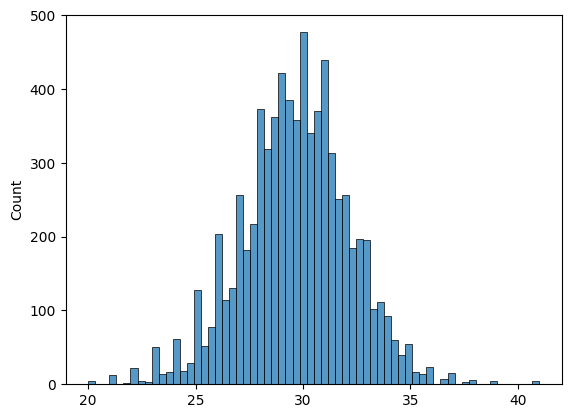

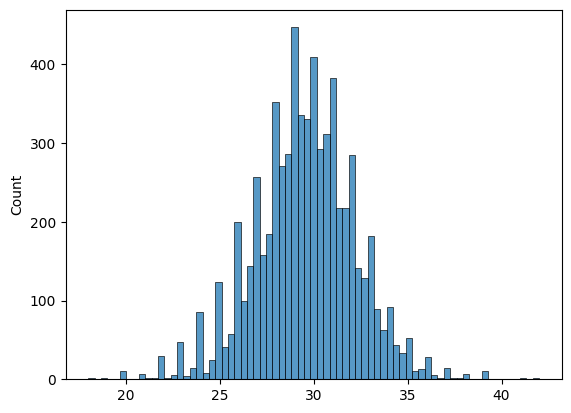

In [212]:
sns.histplot(feat_red)
plt.show()

sns.histplot(feat_blue)
plt.show()

In [213]:
np.isnan(feat_red - feat_blue).sum()

np.int64(1969)

In [138]:
df_combined[df_combined['td_attempted_pm_blue']==0].shape

(735, 218)

In [153]:
import seaborn as sns

<Axes: ylabel='Count'>

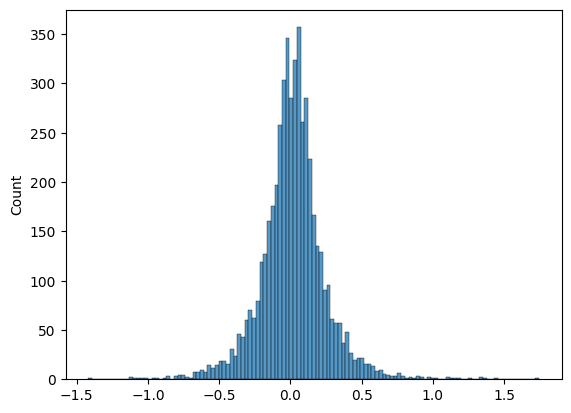

In [154]:
sns.histplot(red_col)